# 05 · One improvement: a state-gated Seq2Point

**Requirement 3, continued.** One targeted change to the reference model, chosen from the
literature for the failure mode that matters most on a sparse appliance, and compared with
Seq2Point under identical data, window, optimiser and seeds.

| | |
|---|---|
| **Input** | the same corpus and window as notebook 04 (`nb04_summary.json`) |
| **Output** | checkpoints `artifacts/models/m3_gated_*`, `artifacts/tables/nb05_validation.csv`, `artifacts/metrics/nb05_summary.json` |
| **Run time** | about 30 minutes on one laptop GPU |

**The failure mode.** A washing machine is off about 97 % of the time. A pure regressor
trained with MSE learns to hedge: during any 2 kW event (kettle, dishwasher, washer-dryer,
shower) it outputs a little washing-machine power "just in case", and in the long tail of a
real cycle it under-predicts. Small ghost power spread over thousands of off-minutes adds up to
real energy error.

**The change.** The convolutional trunk is shared; on top of it sit two heads, a power
regressor and an on/off classifier, and the output power is ``P(on) × power``. The classifier is
trained with binary cross-entropy against the 20 W state label, the product with MSE. This is
the subtask-gating idea of Shin et al. (AAAI 2019); the same two-head structure appears in
UNet-NILM (Faustine et al. 2020) and in Murray et al. (ICASSP 2019) on REFIT, and Precioso &
Gómez-Ullate (2023) argue for exactly this combined classification + regression loss.

**Why this and not something bigger.** It is a single, isolated change (same trunk, same data
pipeline), so the comparison is clean; it directly targets the dominant error; and it produces
a calibrated on-probability that downstream uses (cycle counting, alerts) need. A Transformer
or a dilated residual trunk would change several things at once.

**Honest prior.** No paper reports this exact comparison on REFIT at 1-minute resolution, so a
null result is possible and would be reported as such.

In [1]:
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from refit_nilm import datasets as D
from refit_nilm import metrics, plots
from refit_nilm import config as C
from refit_nilm import train as T

warnings.filterwarnings("ignore", category=FutureWarning)
plots.setup()
pd.set_option("display.width", 160, "display.max_columns", 30)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
nb04 = json.load(open(C.METRIC_DIR / "nb04_summary.json"))
W = int(nb04["window_selection"]["chosen_window"])
frames, corpora, stats = D.prepare([W])
cp, st = corpora[W], stats[W]
print("window:", W)
SUMMARY: dict = {"window": W}


def score(name: str, power: np.ndarray, p_on: np.ndarray | None = None) -> dict:
    starts = cp.starts["val"]
    h = C.VAL_HOUSE
    y = D.to_series(cp, starts, cp.wm[starts + W // 2], h)
    yh = D.to_series(cp, starts, power, h)
    po = D.to_series(cp, starts, p_on, h) if p_on is not None else None
    return {"model": name, **metrics.all_metrics(y, yh, po)}

window: 81


## 1. Choose the state-loss weight λ on the validation house (seed 42)

λ balances the classification and regression terms. Precioso & Gómez-Ullate found the best
weight depends on the appliance, so two values an order of magnitude apart are tried.

In [2]:
rows, histories = [], {}
for lam in (0.1, 1.0):
    cfg = T.TrainConfig(model="gated_seq2point", window=W, seed=42, state_weight=lam)
    t0 = time.time()
    model, hist = T.fit(cp, st, cfg, device=DEVICE)
    T.save_run(C.MODEL_DIR / f"m3_gated_w{W}_l{lam}_s42.pt", model, cfg, st, hist)
    histories[(lam, 42)] = hist
    out = T.predict(model, T.WindowSource(cp, st, DEVICE), cp.starts["val"], st)
    rows.append({"lambda": lam, "seed": 42, **score(f"M3 gated λ={lam} s42", out["power"], out["p_on"])})
    print(f"λ={lam}: {len(hist)} epochs, {time.time() - t0:.0f}s")
    del model
    torch.cuda.empty_cache()
lam_tab = pd.DataFrame(rows)
LAMBDA = float(lam_tab.sort_values("nde").iloc[0]["lambda"])
SUMMARY["lambda_selection"] = {"val_nde": dict(zip(lam_tab["lambda"].astype(str), lam_tab["nde"])), "chosen_lambda": LAMBDA}
lam_tab[["lambda", "mae_w", "mae_on_w", "sae", "nde", "f1", "cycle_f1", "auprc"]].round(3)

epoch  1  train_loss 0.5397  val_NDE 0.8799  val_MAE 9.31 W  (21s)


epoch  2  train_loss 0.3325  val_NDE 1.2552  val_MAE 11.81 W  (18s)


epoch  3  train_loss 0.2341  val_NDE 1.0032  val_MAE 6.43 W  (19s)


epoch  4  train_loss 0.1712  val_NDE 0.8455  val_MAE 5.06 W  (20s)


epoch  5  train_loss 0.1350  val_NDE 1.2305  val_MAE 9.06 W  (20s)


...

epoch  5  train_loss 0.1903  val_NDE 0.9774  val_MAE 7.61 W  (20s)


epoch  6  train_loss 0.1627  val_NDE 0.9276  val_MAE 5.74 W  (20s)


epoch  7  train_loss 0.1447  val_NDE 0.9229  val_MAE 6.40 W  (20s)


λ=1.0: 7 epochs, 140s


,lambda,mae_w,mae_on_w,sae,nde,f1,cycle_f1,auprc
0,0.1,5.056,184.841,0.406,0.846,0.448,0.500,0.433
1,1.0,8.010,189.379,1.181,0.892,0.316,0.488,0.552


## 2. Two more seeds with the chosen λ

In [3]:
for seed in [s for s in C.SEEDS if s != 42]:
    cfg = T.TrainConfig(model="gated_seq2point", window=W, seed=seed, state_weight=LAMBDA)
    model, hist = T.fit(cp, st, cfg, device=DEVICE)
    T.save_run(C.MODEL_DIR / f"m3_gated_w{W}_l{LAMBDA}_s{seed}.pt", model, cfg, st, hist)
    histories[(LAMBDA, seed)] = hist
    out = T.predict(model, T.WindowSource(cp, st, DEVICE), cp.starts["val"], st)
    rows.append({"lambda": LAMBDA, "seed": seed, **score(f"M3 gated λ={LAMBDA} s{seed}", out["power"], out["p_on"])})
    del model
    torch.cuda.empty_cache()

epoch  1  train_loss 0.5635  val_NDE 0.7886  val_MAE 9.61 W  (20s)


epoch  2  train_loss 0.3427  val_NDE 0.9800  val_MAE 8.75 W  (20s)


epoch  3  train_loss 0.2407  val_NDE 0.9535  val_MAE 7.49 W  (20s)


epoch  4  train_loss 0.1731  val_NDE 1.1388  val_MAE 9.54 W  (20s)


epoch  5  train_loss 0.1346  val_NDE 1.1495  val_MAE 7.64 W  (20s)


...

epoch  4  train_loss 0.1920  val_NDE 0.8874  val_MAE 6.25 W  (20s)


epoch  5  train_loss 0.1501  val_NDE 1.0377  val_MAE 7.09 W  (20s)


epoch  6  train_loss 0.1243  val_NDE 1.0112  val_MAE 6.97 W  (20s)


epoch  7  train_loss 0.1052  val_NDE 0.9881  val_MAE 7.89 W  (20s)


epoch  8  train_loss 0.0933  val_NDE 1.0505  val_MAE 8.35 W  (20s)


## 3. Ablation on the validation house: Seq2Point vs gated Seq2Point (3 seeds each)

In [4]:
nb04_val = pd.read_csv(C.TABLE_DIR / "nb04_validation.csv")
s2p = nb04_val[nb04_val.model.str.startswith(f"M2 Seq2Point W={W}")].assign(family="M2 Seq2Point")
gated = pd.DataFrame([r for r in rows if r["lambda"] == LAMBDA]).assign(family="M3 gated Seq2Point")
keep = ["mae_w", "mae_on_w", "sae", "sae_daily", "epd_wh", "nde", "f1", "precision", "recall", "cycle_f1", "overlap_pct", "missing_pct", "extra_pct"]
abl = pd.concat([s2p, gated])
summary = abl.groupby("family")[keep].agg(["mean", "std"]).round(3)
summary.to_csv(C.TABLE_DIR / "nb05_ablation_val.csv")
summary.T

family            M2 Seq2Point  M3 gated Seq2Point
mae_w       mean         5.288               6.862
            std          0.546               2.420
mae_on_w    mean       162.412             181.579
            std          6.648              22.235
sae         mean         0.592               0.880
            std          0.091               0.548
sae_daily   mean         0.328               0.471
            std          0.046               0.017
epd_wh      mean        85.511             116.792
            std          9.382              34.427
nde         mean         0.675               0.826
            std          0.051               0.033
f1          mean         0.426               0.340
            std          0.033               0.129
precision   mean         0.291               0.240
            std          0.029               0.114
recall      mean         0.792               0.659
            std          0.017               0.019
cycle_f1    mean         0.603               0.468
            std          0.016               0.043
overlap_pct mean        61.267              55.323
            std          2.559               5.682
missing_pct mean        38.733              44.677
            std          2.559               5.682
extra_pct   mean        97.913             132.630
            std         11.579              58.529

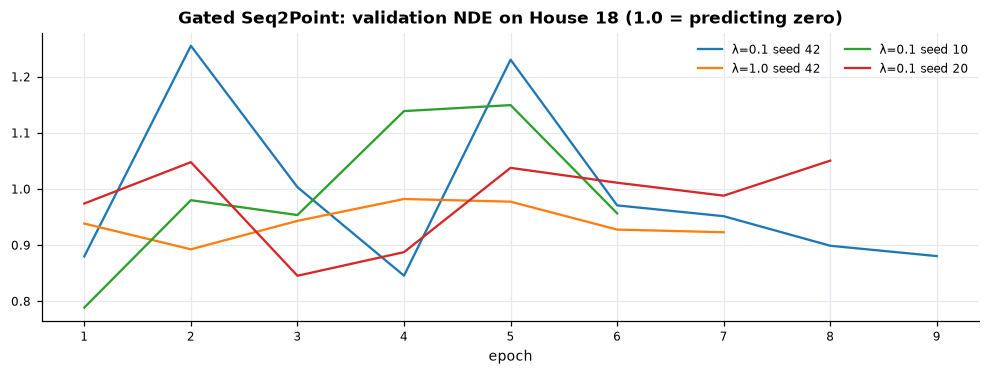

In [5]:
fig, ax = plt.subplots(figsize=(11, 3.4))
for (lam, seed), hist in histories.items():
    h = pd.DataFrame(hist)
    ax.plot(h.epoch, h.val_nde, label=f"λ={lam} seed {seed}")
ax.set_title("Gated Seq2Point: validation NDE on House 18 (1.0 = predicting zero)")
ax.set_xlabel("epoch")
ax.legend(ncol=2)
plots.save(fig, "nb05_learning_curves")
plt.show()

In [6]:
pd.DataFrame(rows).to_csv(C.TABLE_DIR / "nb05_validation.csv", index=False)
SUMMARY["ablation_val"] = {fam: {m: float(summary.loc[fam, (m, "mean")]) for m in keep} for fam in summary.index}
with open(C.METRIC_DIR / "nb05_summary.json", "w") as fh:
    json.dump(SUMMARY, fh, indent=2, default=str)

## Summary

**λ.** 0.1 was kept (validation NDE 0.85 vs 0.89 for λ = 1 at seed 42).

**Ablation on the validation house (House 18), mean ± sd over three seeds, W = 81.**

| | Seq2Point (M2) | gated Seq2Point (M3) |
|---|---|---|
| NDE | **0.68 ± 0.05** | 0.83 ± 0.03 |
| MAE (W) | **5.3 ± 0.5** | 6.9 ± 2.4 |
| daily energy error, EpD (Wh/day) | **86 ± 9** | 117 ± 34 |
| F1 (minute on/off) | **0.43 ± 0.03** | 0.34 ± 0.13 |
| cycle F1 | **0.60 ± 0.02** | 0.47 ± 0.04 |
| true energy recovered | **61 %** | 55 % |
| extra (false) energy | **98 %** | 133 % |

**Verdict: the gate made things worse, on every metric, and less stable across seeds.** This is
a negative result, and it is reported as one.

**Why, mechanistically.** The gated models reach their best validation score after only 1–4
epochs and then degrade, while plain Seq2Point keeps improving for ~10. The on/off head learns
home-specific cues quickly; in an unseen home, a *confident* gate turns an ambiguous 2 kW event
into a full-power false cycle. Plain Seq2Point, trained with MSE, hedges on the same event with a
lower output, which costs less energy error. Gating suppresses false power only when the
classifier generalises, and here it is the classifier that does not.

**Consequence.** Seq2Point remains the reference model. The gate addressed the symptom (power
during "off"); notebook 05b looks for the cause of the false positives on the validation house
and tests a change aimed at it.